# Shor's Algorithm

## Lecture 4

### Last Time
1. Quantum Fourier Transform (QFT)
2. Quantum Phase Estimation (QPE)

### Today
1. Turn factoring into order finding
2. Use QPE to estimate the order
3. Recover the factors with classical post-processing
4. Simulate a complete small example: $21=3\cdot 7$

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import math
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=3, suppress=True)


def bits(j, n):
    return format(j, f'0{n}b')


def gcf(a, b):
    return math.gcd(a, b)


# The Idea Behind Shor's

Shor's algorithm factors a large integer $N$ by turning factoring into a period-finding problem.

The quantum computer does **not** directly output the factors. Instead, it finds a hidden period $r$ in

$$f(x)=g^x \bmod N.$$

QPE and the QFT are tools that converts this hidden period into a measurable quantity.

## Factoring becomes order finding

We will write the greatest common factor of $g$ and $N$ as

$$d=\operatorname{gcf}(g,N).$$

$d$ is the largest integer that divides both $g$ and $N$.

If $d>1$, then it is a nontrivial factor of $N$. At that point, factoring has already succeeded.

However, if $d = \operatorname{gcf}(g,N)=1$, then $g$ has no factor in common with $N$.

Suppose $d = 1$. That means every power of $g$ also has no factor in common with $N$, so the powers stay among the invertible remainders modulo $N$:

$$g^0,g^1,g^2,g^3,\ldots \pmod N.$$

There are only finitely many possible remainders, so two powers must eventually match:

$$g^a\equiv g^b\pmod N\qquad (b>a).$$

Because $g^a$ has an inverse modulo $N$, we can cancel it from both sides:

$$g^{b-a}\equiv 1\pmod N.$$

So the powers repeat, and the **order** of $g$ modulo $N$ is the smallest positive repeat back to $1$:

$$g^r \equiv 1 \pmod N.$$

Equivalently,

$$g^r-1=mN$$

for some integer $m$.

## From the order to factors

If the order $r$ is even, then

$$mN = g^r-1=\left(g^{r/2}\right)^2-1=(g^{r/2}-1)(g^{r/2}+1).$$

So, $(g^{r/2}-1)(g^{r/2}+1)$ divides $N$:

$$N \mid (g^{r/2}-1)(g^{r/2}+1).$$

If $g^{r/2}\equiv -1\pmod N$, then

$$g^{r/2}+1\equiv 0\pmod N,$$

so the greatest common factor calculation can give back the boring factor $N$ instead of a smaller factor.

When $g^{r/2}\not\equiv -1\pmod N$, compute

$$\operatorname{gcf}(g^{r/2}-1,N),\qquad \operatorname{gcf}(g^{r/2}+1,N).$$

With good probability, these are nontrivial factors.

## The full algorithm in one picture

Input: an odd composite integer $N$ that we want to factor.

1. Pick a random integer $g$ with $1<g<N$.
2. Compute $d=\text{gcf}(g,N)$.
3. If $d>1$, we already found a factor.
4. Otherwise, use a quantum computer to find the order $r$ of $g$ modulo $N$:

$$g^r\equiv 1 \pmod N.$$

5. If $r$ is even and $g^{r/2}\not\equiv -1\pmod N$, compute

$$\text{gcf}(g^{r/2}-1,N),\qquad \text{gcf}(g^{r/2}+1,N).$$

Those are usually nontrivial factors of $N$.

## Small example: $N=15$

Let

$$N=15=3\cdot 5,\qquad g=4.$$

Check powers modulo $15$:

$$4^1\equiv 4\pmod {15},$$

$$4^2=16\equiv 1\pmod {15}.$$

So the order is $r=2$.

Then

$$g^{r/2}=4^1=4,$$

and

$$\operatorname{gcf}(4-1,15)=\operatorname{gcf}(3,15)=3,$$

$$\operatorname{gcf}(4+1,15)=\operatorname{gcf}(5,15)=5.$$

For $N=15$ we got lucky: the guess worked and the period was tiny.

## A slightly larger example: $N=21$

Choose

$$N=21=3\cdot 7,\qquad g=2.$$

First check that this guess is not already sharing a factor:

$$\text{gcf}(2,21)=1.$$

Now compute powers of $2$ modulo $21$:

| $x$ | $2^x$ | $2^x \bmod 21$ |
|---:|---:|---:|
| 0 | 1 | 1 |
| 1 | 2 | 2 |
| 2 | 4 | 4 |
| 3 | 8 | 8 |
| 4 | 16 | 16 |
| 5 | 32 | 11 |
| 6 | 64 | 1 |

The first positive return to $1$ is $r=6$.

Since $r=6$ is even,

$$g^{r/2}=2^3=8.$$

Now compute two greatest common factors:

$$\text{gcf}(8-1,21)=\text{gcf}(7,21)=7,$$

$$\text{gcf}(8+1,21)=\text{gcf}(9,21)=3.$$

So the factors are

$$21=3\cdot 7.$$

For a real input, the hard part is not the final GCF step. The hard part is finding $r$.

# The Quantum Subroutine

The quantum part of Shor's algorithm is an order-finding machine.

For a chosen base $g$, define the modular multiplication unitary

$$U_g|y\rangle=|gy\bmod N\rangle.$$

Because $\text{gcf}(g,N)=1$, multiplication by $g$ modulo $N$ is reversible: every allowed residue maps to a unique allowed residue.

That is why $U_g$ is a valid quantum operation.

## Why powers of $U_g$ matter

Applying $U_g$ once multiplies by $g$:

$$U_g|y\rangle=|gy\bmod N\rangle.$$

Applying it twice multiplies by $g^2$:

$$U_g^2|y\rangle=|g^2y\bmod N\rangle.$$

In general,

$$U_g^x|y\rangle=|g^xy\bmod N\rangle.$$

QPE needs controlled versions of $U_g^{x}$.

## The orbit starting from $|1\rangle$

If we start the work register in $|1\rangle$, repeated applications of $U_g$ walk around the cycle

$$|1\rangle, |g\bmod N\rangle, |g^2\bmod N\rangle,\ldots, |g^{r-1}\bmod N\rangle,$$

and then return to $|1\rangle$.

For $N=21$, $g=2$, the orbit is

$$|1\rangle\to |2\rangle\to |4\rangle\to |8\rangle\to |16\rangle\to |11\rangle\to |1\rangle.$$

That cycle length is exactly the order $r=6$.

## Eigenvectors hiding in the cycle

QPE estimates phases of eigenvectors. The cycle states can be combined into eigenvectors of $U_g$.

For $k=0,1,\ldots,r-1$, define

$$|\zeta_k\rangle=\frac{1}{\sqrt r}\sum_{j=0}^{r-1} e^{-2\pi i k j/r}|g^j\bmod N\rangle.$$

Now apply $U_g$:

$$U_g|g^j\bmod N\rangle=|g^{j+1}\bmod N\rangle.$$

So $U_g$ shifts every term one step around the cycle. A shifted Fourier wave is the same wave times a phase.

## The eigenvalue calculation

Start with

$$|\zeta_k\rangle=\frac{1}{\sqrt r}\sum_{j=0}^{r-1} e^{-2\pi i k j/r}|g^j\bmod N\rangle.$$

Apply $U_g$:

$$U_g|\zeta_k\rangle
=\frac{1}{\sqrt r}\sum_{j=0}^{r-1} e^{-2\pi i k j/r}|g^{j+1}\bmod N\rangle.$$

Let $\ell=j+1$. Then $j=\ell-1$, so

$$U_g|\zeta_k\rangle
=\frac{1}{\sqrt r}\sum_{\ell=0}^{r-1} e^{-2\pi i k (\ell-1)/r}|g^{\ell}\bmod N\rangle.$$

Pull out the extra factor:

$$U_g|\zeta_k\rangle=e^{2\pi i k/r}|\zeta_k\rangle.$$

The phase is

$$\theta=\frac{k}{r}.$$

## But we do not prepare $|\zeta_k\rangle$

The convenient state is just $|1\rangle$.

The key fact is that $|1\rangle$ is an equal superposition of the eigenvectors on the cycle:

$$|1\rangle=\frac{1}{\sqrt r}\sum_{k=0}^{r-1}|\zeta_k\rangle.$$

So if we run QPE with work register $|1\rangle$, the measurement effectively chooses a random $k$ and estimates

$$\theta=\frac{k}{r}.$$

We do not control which $k$ we get, but many values of $k$ are useful enough to recover $r$.

# QPE for Order Finding

Use $m$ counting qubits and let

$$Q=2^m.$$

After the Hadamards on the counting register:

$$\frac{1}{\sqrt Q}\sum_{x=0}^{Q-1}|x\rangle|\psi\rangle.$$

Controlled powers of $U_g$ create phase kickback:

$$|x\rangle|\zeta_k\rangle
\mapsto
|x\rangle U_g^x|\zeta_k\rangle
=
e^{2\pi i xk/r}|x\rangle|\zeta_k\rangle.$$

So the counting register becomes

$$\frac{1}{\sqrt Q}\sum_{x=0}^{Q-1} e^{2\pi i xk/r}|x\rangle.$$

The inverse QFT converts this phase slope into a computational basis value near

$$y\approx Q\frac{k}{r}.$$

## What the measurement gives us

The quantum computer returns an integer $y$.

We divide by $Q=2^m$:

$$\frac{y}{Q}\approx \frac{k}{r}.$$

At this point, the quantum part is over.

The remaining problem is classical:

> Given a decimal/binary approximation to $k/r$, recover the denominator $r$.

That is exactly what continued fractions are good at.

## Continued Fractions

A continued fraction writes a number as

$$a_0+\cfrac{1}{a_1+\cfrac{1}{a_2+\cfrac{1}{a_3+\cdots}}}.$$

If a number is very close to a rational fraction with a small denominator, its continued-fraction convergents reveal that fraction.

In Python, `Fraction(y, Q).limit_denominator(N)` performs this recovery step for us.

For Shor's algorithm, the denominator candidate is our possible order $r$.

## Continued fractions: step by step

Suppose QPE gives a measurement $y$ and $Q=2^m$.

We form the rational number

$$R=\frac{y}{Q}.$$

A continued fraction repeatedly does this:

1. take the integer part,
2. subtract it off,
3. flip the remaining fraction,
4. repeat.

Symbolically,

$$R=a_0+\frac{1}{a_1+\frac{1}{a_2+\cdots}}.$$

If $R$ is close to some simple fraction $k/r$, then one of the early **convergents** of this continued fraction is usually $k/r$.

## Continued fractions example from our run

For $N=21$ and $g=2$, one useful QPE outcome is

$$y=171,\qquad Q=2^{10}=1024.$$

So

$$R=\frac{171}{1024}\approx 0.166992.$$

Now run the continued-fraction divisions:

| Step | Division | Quotient | Remainder |
|---:|---|---:|---:|
| 1 | $1024=5\cdot171+169$ | 5 | 169 |
| 2 | $171=1\cdot169+2$ | 1 | 2 |
| 3 | $169=84\cdot2+1$ | 84 | 1 |
| 4 | $2=2\cdot1+0$ | 2 | 0 |

Because $171/1024<1$, the continued fraction starts with $0$:

$$\frac{171}{1024}=[0;5,1,84,2].$$

## Continued fractions: convergents

The convergents are what you get by stopping the continued fraction early.

For

$$\frac{171}{1024}=[0;5,1,84,2],$$

we get:

| Stop here | Convergent | Decimal |
|---:|---:|---:|
| $[0]$ | $0$ | $0$ |
| $[0;5]$ | $1/5$ | $0.2$ |
| $[0;5,1]$ | $1/6$ | $0.166667$ |
| $[0;5,1,84]$ | $85/509$ | $0.166994$ |
| $[0;5,1,84,2]$ | $171/1024$ | $0.166992$ |

We can stop at the first number that passes the order test $g^r \equiv 1 (\text{mod }N)$. Note that we dont need to test every single possible value for $r$.

The useful candidate is

$$\frac{k}{r}=\frac{1}{6},\qquad r=6.$$

## Check the recovered order

A continued fraction only gives a **candidate** order.

For $N=21$, $g=2$, and candidate $r=6$, check:

$$2^6=64\equiv 1\pmod{21}.$$

So $r=6$ passes the order test.

Then

$$2^{r/2}=2^3=8,$$

and the factors come from

$$\text{gcf}(8-1,21)=\text{gcf}(7,21)=7,$$

$$\text{gcf}(8+1,21)=\text{gcf}(9,21)=3.$$

This is the exact bridge from the QPE measurement to the factorization.

## Classical post-processing checklist

Given a measurement $y$:

1. Compute a fraction close to $y/Q$:

$$\frac{y}{Q}\approx \frac{k}{r}.$$

2. Let the denominator be a candidate order $r$.
3. Check that it is actually an order:

$$g^r\equiv 1\pmod N.$$

4. Check that $r$ is even.
5. Check that

$$g^{r/2}\not\equiv -1\pmod N.$$

6. Compute the two GCFs.

If any check fails, use another measurement or choose a new base $g$.

## How many qubits do we need?

Let the integer to be factored have $n$ bits, so

$$2^{n-1}\le N<2^n.$$

The standard QPE version uses:

| Register | Purpose | Size |
|---|---|---:|
| Counting register | estimates $k/r$ | about $2n$ qubits |
| Work register | stores numbers modulo $N$ | $n$ qubits |
| Arithmetic workspace | reversible modular multiplication | implementation-dependent |

So the clean scaling is

$$\text{logical qubits}=O(n).$$

A simple lecture-level count is about

$$3n\text{ main qubits}$$

plus extra ancillas for efficient reversible arithmetic. Gate counts are polynomial, commonly summarized as about $O(n^3)$ elementary arithmetic gates in textbook constructions.

# Code: Building Blocks

Now we will simulate the order-finding subroutine for

$$N=21,\qquad g=2.$$

This is small enough that we can build modular multiplication as an explicit unitary matrix.

That is not how a large fault-tolerant implementation would be built, but it is perfect for seeing the algorithm end-to-end.

In [2]:
def qft_circuit(n, do_swaps=True):
    qc = QuantumCircuit(n, name='QFT')
    for target in reversed(range(n)):
        qc.h(target)
        for control in reversed(range(target)):
            angle = np.pi / (2 ** (target - control))
            qc.cp(angle, control, target)
        qc.barrier()
    if do_swaps:
        for q in range(n // 2):
            qc.swap(q, n - q - 1)
    return qc


def modular_multiply_gate(multiplier, N, n_work):
    """Return |y> -> |multiplier*y mod N> for y<N, identity for y>=N."""
    dim = 2 ** n_work
    U = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        out = (multiplier * y) % N if y < N else y
        U[out, y] = 1
    return UnitaryGate(U, label=f'x{multiplier} mod {N}')

In [3]:
def shor_order_finding_circuit(g, N, m_counting=None, measure=False):
    n_work = math.ceil(math.log2(N))
    if m_counting is None:
        m_counting = 2 * N.bit_length()

    counting = QuantumRegister(m_counting, name='count')
    work = QuantumRegister(n_work, name='work')

    if measure:
        readout = ClassicalRegister(m_counting, name='readout')
        qc = QuantumCircuit(counting, work, readout)
    else:
        qc = QuantumCircuit(counting, work)

    # Work register starts in |1>.
    qc.x(work[0])

    # Counting register starts in a uniform superposition over x.
    for q in counting:
        qc.h(q)

    qc.barrier()

    # Controlled U_g^(2^j). Since U_g^(2^j) multiplies by g^(2^j) mod N,
    # we can precompute each multiplier classically.
    for j, q in enumerate(counting):
        multiplier = pow(g, 2 ** j, N)
        controlled_mult = modular_multiply_gate(multiplier, N, n_work).control(1)
        qc.append(controlled_mult, [q] + list(work))

    qc.barrier()

    # Inverse QFT reads the phase back into the counting register.
    qc.append(qft_circuit(m_counting).inverse(), counting)

    if measure:
        qc.measure(counting, readout)

    return qc

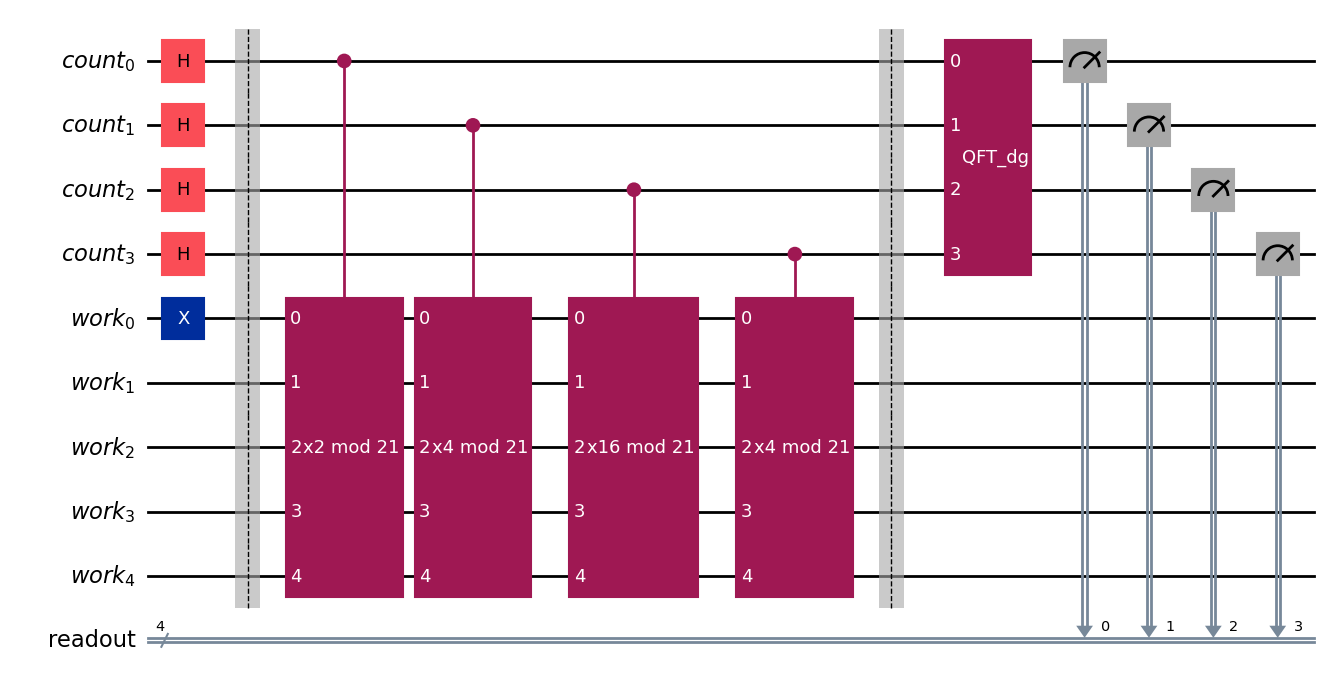

In [4]:
# A tiny circuit drawing so the structure is visible on a slide.
small_demo = shor_order_finding_circuit(g=2, N=21, m_counting=4, measure=True)
small_demo.draw(output='mpl')

## Simulating the phase distribution

For the actual demonstration we use

$$m=2n$$

counting qubits, where $n$ is the bit length of $N$.

For $N=21$, $n=5$, so we use $m=10$ counting qubits.

The true order of $2$ modulo $21$ is $r=6$, so the ideal peaks are near

$$y\approx 2^{10}\frac{k}{6}.$$

That means we expect peaks near

$$0,171,341,512,683,853.$$

In [5]:
def phase_probabilities_from_statevector(qc, m_counting, cutoff=1e-6):
    state = Statevector.from_instruction(qc)
    probabilities = state.probabilities_dict(qargs=range(m_counting))
    return {bits: float(prob) for bits, prob in probabilities.items() if prob > cutoff}


N = 21
g = 2
m_counting = 2 * N.bit_length()
Q = 2 ** m_counting

qc = shor_order_finding_circuit(g, N, m_counting=m_counting, measure=False)
phase_probs = phase_probabilities_from_statevector(qc, m_counting)

print(f'N = {N}, g = {g}')
print(f'counting qubits m = {m_counting}, Q = 2^m = {Q}')
print(f'total qubits in this simulation = {qc.num_qubits}')
print('largest measurement probabilities:')
for bit_string, prob in sorted(phase_probs.items(), key=lambda item: item[1], reverse=True)[:12]:
    y = int(bit_string, 2)
    frac = Fraction(y, Q).limit_denominator(N)
    print(f'  bits={bit_string}, y={y:4d}, probability={prob:.4f}, y/Q≈{frac}')

N = 21, g = 2
counting qubits m = 10, Q = 2^m = 1024
total qubits in this simulation = 15
largest measurement probabilities:
  bits=0000000000, y=   0, probability=0.1667, y/Q≈0
  bits=1000000000, y= 512, probability=0.1667, y/Q≈1/2
  bits=0010101011, y= 171, probability=0.1140, y/Q≈1/6
  bits=1010101011, y= 683, probability=0.1140, y/Q≈2/3
  bits=1101010101, y= 853, probability=0.1140, y/Q≈5/6
  bits=0101010101, y= 341, probability=0.1140, y/Q≈1/3
  bits=0010101010, y= 170, probability=0.0285, y/Q≈1/6
  bits=1010101010, y= 682, probability=0.0285, y/Q≈2/3
  bits=1101010110, y= 854, probability=0.0285, y/Q≈5/6
  bits=0101010110, y= 342, probability=0.0285, y/Q≈1/3
  bits=0010101100, y= 172, probability=0.0071, y/Q≈1/6
  bits=1010101100, y= 684, probability=0.0071, y/Q≈2/3


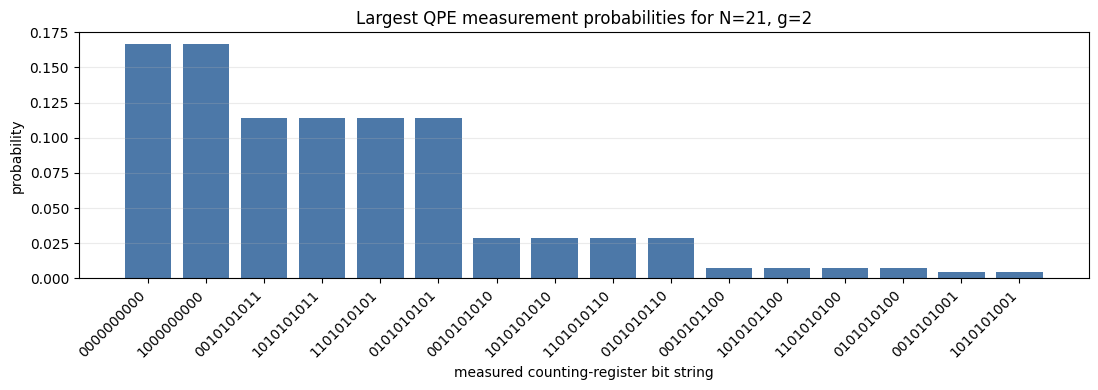

In [6]:
top_items = sorted(phase_probs.items(), key=lambda item: item[1], reverse=True)[:16]
labels = [item[0] for item in top_items]
values = [item[1] for item in top_items]

plt.figure(figsize=(11, 4))
plt.bar(labels, values, color='#4c78a8')
plt.xticks(rotation=45, ha='right')
plt.ylabel('probability')
plt.xlabel('measured counting-register bit string')
plt.title('Largest QPE measurement probabilities for N=21, g=2')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()

## Recovering the factors from measurements

Some measurements are not useful.

For example, if QPE returns $y=0$, then

$$y/Q=0,$$

which does not reveal the denominator $r=6$.

If QPE returns a value near $Q/2$, continued fractions may return $1/2$, whose denominator is $2$ rather than $6$.

So the classical routine tries likely measurements until it finds a denominator that passes the order checks.

In [7]:
def try_recover_factors_from_y(y, Q, g, N):
    frac = Fraction(y, Q).limit_denominator(N)
    r_candidate = frac.denominator

    details = {
        'y': y,
        'fraction': frac,
        'r_candidate': r_candidate,
    }

    if r_candidate <= 0:
        return None, details
    if pow(g, r_candidate, N) != 1:
        details['reason'] = 'candidate r does not satisfy g^r = 1 mod N'
        return None, details
    if r_candidate % 2 != 0:
        details['reason'] = 'candidate r is odd'
        return None, details

    x = pow(g, r_candidate // 2, N)
    if x == N - 1:
        details['reason'] = 'g^(r/2) = -1 mod N'
        return None, details

    factor1 = gcf(x - 1, N)
    factor2 = gcf(x + 1, N)
    if factor1 in (1, N) or factor2 in (1, N):
        details['reason'] = 'GCF returned a trivial factor'
        return None, details

    details['x'] = x
    return tuple(sorted((factor1, factor2))), details


def factor_from_qpe_distribution(phase_probs, Q, g, N):
    attempts = []
    for bit_string, prob in sorted(phase_probs.items(), key=lambda item: item[1], reverse=True):
        y = int(bit_string, 2)
        factors, details = try_recover_factors_from_y(y, Q, g, N)
        details['bits'] = bit_string
        details['probability'] = prob
        attempts.append(details)
        if factors is not None:
            return factors, details, attempts
    return None, None, attempts


factors, success, attempts = factor_from_qpe_distribution(phase_probs, Q, g, N)
print('successful measurement:')
for key in ['bits', 'y', 'probability', 'fraction', 'r_candidate', 'x']:
    print(f'  {key}: {success[key]}')
print(f'\nRecovered factors of {N}: {factors[0]} and {factors[1]}')
print(f'Check: {factors[0]} * {factors[1]} = {factors[0] * factors[1]}')

successful measurement:
  bits: 0010101011
  y: 171
  probability: 0.11398712783346579
  fraction: 1/6
  r_candidate: 6
  x: 8

Recovered factors of 21: 3 and 7
Check: 3 * 7 = 21


# Complete Classical Wrapper

The previous cells used a chosen base $g=2$.

A complete Shor wrapper repeats the process if the base is unlucky:

- if $\text{gcf}(g,N)>1$, we are done immediately,
- if QPE gives an unusable order candidate, try another measurement or another $g$,
- if $r$ is odd, try again,
- if $g^{r/2}\equiv -1\pmod N$, try again.

For classroom simulation, we keep $g=2$ so the output is deterministic and easy to inspect.

In [8]:
def factor_demo():
    N = 21
    g = 2

    d = gcf(g, N)
    if d > 1:
        return d, N // d

    m_counting = 2 * N.bit_length()
    Q = 2 ** m_counting
    qc = shor_order_finding_circuit(g, N, m_counting=m_counting, measure=False)
    phase_probs = phase_probabilities_from_statevector(qc, m_counting)
    factors, success, _ = factor_from_qpe_distribution(phase_probs, Q, g, N)

    if factors is None:
        raise RuntimeError('No usable order was recovered. Try another base g.')

    print(f'Shor simulation for N={N}, base g={g}')
    print(f'QPE measurement used: {success["bits"]}  (y={success["y"]})')
    print(f'Continued fraction: {success["fraction"]}')
    print(f'Recovered order r={success["r_candidate"]}')
    print(f'g^(r/2) mod N = {success["x"]}')
    print(f'Factors: {factors[0]} and {factors[1]}')
    return factors

factor_demo()

Shor simulation for N=21, base g=2
QPE measurement used: 0010101011  (y=171)
Continued fraction: 1/6
Recovered order r=6
g^(r/2) mod N = 8
Factors: 3 and 7


(3, 7)

# IBM Quantum Hardware Template

The next cell is a **template** to run Shor's algorithm on IBM's Quantum Hardware.

It is intentionally not run in this notebook because it requires:

1. an IBM Quantum account,
2. an API token or saved account credentials,
3. an available backend,
4. the `qiskit-ibm-runtime` package installed.

The circuit construction is the same, but real hardware will be noisy. A 15-qubit order-finding circuit with large controlled modular multiplication gates is already ambitious for current devices, so students should treat this as a starting point for transpilation experiments, not a guaranteed hardware success.

In [9]:
RUN_ON_IBM_HARDWARE = False

if RUN_ON_IBM_HARDWARE:
    # Install first if needed:
    #   pip install qiskit-ibm-runtime
    #
    # Save credentials once, outside the notebook or in a private setup cell:
    #   from qiskit_ibm_runtime import QiskitRuntimeService
    #   QiskitRuntimeService.save_account(
    #       channel='ibm_quantum_platform',
    #       token='PASTE_YOUR_PRIVATE_IBM_QUANTUM_TOKEN_HERE',
    #       overwrite=True,
    #   )

    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

    service = QiskitRuntimeService(channel='ibm_quantum_platform')

    # Choose a backend you have access to. Students can also inspect:
    # service.backends(simulator=False, operational=True)
    backend = service.least_busy(
        simulator=False,
        operational=True,
        min_num_qubits=15,
    )

    N = 21
    g = 2
    m_counting = 2 * N.bit_length()
    hardware_circuit = shor_order_finding_circuit(g, N, m_counting=m_counting, measure=True)

    # IBM Runtime expects circuits transpiled to the target backend's instruction set.
    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=3,
    )
    isa_circuit = pass_manager.run(hardware_circuit)

    sampler = Sampler(mode=backend)
    job = sampler.run([isa_circuit], shots=4096)
    result = job.result()

    # SamplerV2 result objects expose classical data by register name.
    # Depending on installed versions, students may need to inspect result[0].data.
    counts = result[0].data.readout.get_counts()
    print('backend:', backend.name)
    print('job id:', job.job_id())
    print(counts)

    # Classical post-processing of hardware counts.
    Q = 2 ** m_counting
    hardware_probs = {bits: count / 4096 for bits, count in counts.items()}
    factors, success, attempts = factor_from_qpe_distribution(hardware_probs, Q, g, N)
    print('factors:', factors)
else:
    print('IBM hardware cell is a template. Set RUN_ON_IBM_HARDWARE = True after adding account credentials.')


IBM hardware cell is a template. Set RUN_ON_IBM_HARDWARE = True after adding account credentials.


# Complexity: Why Shor offers a Dramatic Speedup

Classically, factoring is not known to be polynomial time.

The best general-purpose classical factoring algorithm is the **General Number Field Sieve** (GNFS).

For an integer $N$, its asymptotic running time is usually written as

$$\exp\left(\left((64/9)^{1/3}+o(1)\right)(\ln N)^{1/3}(\ln\ln N)^{2/3}\right).$$

This is **subexponential**, but still superpolynomial.

In terms of the bit length $n=\log_2 N$, this is roughly

$$\exp\left(O\left(n^{1/3}(\log n)^{2/3}\right)\right).$$

## Shor's complexity in the ideal circuit model

Shor's algorithm has polynomial scaling in the bit length $n$.

The expensive part is modular exponentiation:

$$|x\rangle|1\rangle\mapsto |x\rangle|g^x\bmod N\rangle.$$

A standard textbook summary is:

| Part | Rough cost |
|---|---:|
| QFT / inverse QFT | $O(n^2)$ gates |
| Reversible modular arithmetic | about $O(n^3)$ gates |
| Continued fractions and GCF | polynomial classical time |

So the idealized total quantum gate count is commonly summarized as about

$$O(n^3)$$

up to implementation details and constant factors.

## Classical vs quantum scaling

Let $n$ be the number of bits of the integer being factored.

| Method | Scaling idea |
|---|---:|
| Trial division | exponential in $n$ |
| Older sieve methods | faster, still superpolynomial |
| GNFS | $\exp(O(n^{1/3}(\log n)^{2/3}))$ |
| Shor, ideal quantum circuit | polynomial, roughly $O(n^3)$ gates |

The point is not that Shor makes factoring small numbers easy.

The point is asymptotic: as $n$ grows, polynomial scaling eventually beats subexponential classical scaling by an enormous margin.

# Ideal qubit count for an $n$-bit integer

Assume an ideal, noiseless quantum computer with no error correction overhead.

For an $n$-bit integer $N$:

| Register | Size | Why |
|---|---:|---|
| Counting register | about $2n$ qubits | enough precision to recover $k/r$ |
| Work register | $n$ qubits | stores residues modulo $N$ |
| Arithmetic ancillas | $O(n)$ qubits | temporary workspace for reversible multiplication |

So a clean rough estimate is

$$\text{ideal logical qubits}=O(n).$$

A simple mental model is

$$\text{about }3n\text{ to }5n\text{ qubits}$$

for an ideal circuit design, before any noise, routing, compilation, or error-correction overhead.

## Summary of the Key Ideas

Shor's algorithm is powerful because it rearranges factoring into a problem quantum computers are good at:

$$\text{factoring}\to\text{order finding}\to\text{phase estimation}.$$

The quantum computer estimates a phase close to

$$\frac{k}{r},$$

and classical continued fractions recover the order $r$.

Once $r$ is known, the factors come from

$$\text{gcf}(g^{r/2}-1,N),\qquad \text{gcf}(g^{r/2}+1,N).$$